**Laboratorio 4: no grafico**

**Estudiante: Huarachi Clemente Ariel**

**Materia: Inteligencia Artificial I**

**Dataset: Desafío de clasificación de productos del Grupo Otto**

**Descripcion del data set:  Este dataset fue publicado por el Grupo Otto, que es una de las empresas de comercio electrónico y venta por catálogo más grandes del mundo (operan en más de 20 países)**

**PREPARACION DE LAS LIBRERIAS**

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Configuración de gráficos
%matplotlib inline

**CARGA BALANCEO Y DIVISION DE LOS DATOS**


In [4]:
# 1. Definir la ruta y cargar con Pandas
ruta_archivo = "train.csv"
df = pd.read_csv(ruta_archivo)

# 2. Mapear etiquetas de texto a números (1 al 9)
diccionario_clases = {f'Class_{i}': i for i in range(1, 10)}
df['target'] = df['target'].map(diccionario_clases)

# --- BALANCEO DEL DATASET ---
# Buscamos cuántos ejemplos tiene la clase más pequeña
min_ejemplos = df['target'].value_counts().min()
print(f"Balanceando clases... Cada clase tendrá {min_ejemplos} ejemplos.")

# Creamos un nuevo DataFrame balanceado tomando la misma cantidad de cada clase
df_balanceado = df.groupby('target').apply(lambda x: x.sample(min_ejemplos, random_state=42)).reset_index(drop=True)

# Mezclamos los datos (shuffle) para que no queden ordenados por clase
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Separar X e y del dataset BALANCEADO
X_total = df_balanceado.drop(['id', 'target'], axis=1).values
y_total = df_balanceado['target'].values

# --- REGLA: PARTICIÓN 80% ENTRENAMIENTO Y 20% PRUEBA ---
m_total = len(y_total)
m_train = int(m_total * 0.8)

# El 80% para entrenar
X_train = X_total[:m_train, :]
y_train = y_total[:m_train]

# El 20% para probar (estos datos NO se usan en el entrenamiento)
X_test = X_total[m_train:, :]
y_test = y_total[m_train:]

# 4. Definir la cantidad de etiquetas
num_labels = 9

print("\n--- RESUMEN FINAL DE DATOS ---")
print(f"Total ejemplos balanceados (m): {m_total}")
print(f"Entrenamiento (80%): {X_train.shape[0]} filas")
print(f"Prueba (20%): {X_test.shape[0]} filas")
print(f"Propiedades (n): {X_train.shape[1]}")

Balanceando clases... Cada clase tendrá 1929 ejemplos.

--- RESUMEN FINAL DE DATOS ---
Total ejemplos balanceados (m): 17361
Entrenamiento (80%): 13888 filas
Prueba (20%): 3473 filas
Propiedades (n): 93


C:\Users\ariel\AppData\Local\Temp\ipykernel_11984\3644382897.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceado = df.groupby('target').apply(lambda x: x.sample(min_ejemplos, random_state=42)).reset_index(drop=True)


**NORMALIZACION DE LAS CARACTERISTICAS**

In [5]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar división por cero si una columna tiene valores constantes
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# 1. Calculamos mu y sigma usando SOLO el 80% de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# 2. Aplicamos los mismos valores de mu y sigma al 20% de prueba
X_test_norm = (X_test - mu) / sigma

print("--- NORMALIZACIÓN COMPLETADA ---")
print(f"X_train_norm listo: {X_train_norm.shape}")
print(f"X_test_norm listo: {X_test_norm.shape}")

--- NORMALIZACIÓN COMPLETADA ---
X_train_norm listo: (13888, 93)
X_test_norm listo: (3473, 93)


**FUNCIONES MATEMATICAS DE COSTO Y SIGMOIDE**


In [6]:
def calcularSigmoide(z):
    # Evita desbordamiento numérico
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(theta, X, y, lambda_):
    m = y.size

    # Aseguramos que y sea entero (por si acaso vienen booleanos)
    if y.dtype == bool:
        y = y.astype(int)

    # 1. Cálculo de la Hipótesis
    h = calcularSigmoide(X.dot(theta)) # Simplificamos el producto punto

    # 2. Protección contra log(0)
    h = np.clip(h, 1e-15, 1 - 1e-15)

    # 3. Regularización: no penalizamos el término de sesgo (theta[0])
    temp = theta.copy()
    temp[0] = 0

    # 4. Función de Costo J con Regularización
    # Usamos np.dot o np.sum para que sea vectorizado y rápido
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # 5. Cálculo del Gradiente
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

**ENTRENAMIENTO DEL MODELO UNO CONTRA TODOS**


In [7]:
def oneVsAll(X, y, num_labels, lambda_, alpha, num_iters):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    # Lista para guardar el historial de costo de cada uno de los 9 clasificadores
    all_J_history = []

    # 1. Agregar la columna de unos a la matriz X (término de intercepción/bias)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # 2. Entrenar un clasificador para cada clase (1 al 9)
    for c in range(1, num_labels + 1):
        theta = np.zeros(n + 1)
        y_c = (y == c).astype(int) # 1 si es la clase actual, 0 para todas las demás
        J_history = np.zeros(num_iters)

        print(f"Entrenando clasificador para la Clase {c}...")

        # Bucle de Descenso por el Gradiente manual
        for i in range(num_iters):
            # Usamos la función calcularCosto que definimos antes
            costo, grad = calcularCosto(theta, X, y_c, lambda_)
            theta = theta - (alpha * grad)
            J_history[i] = costo

        all_theta[c - 1, :] = theta
        all_J_history.append(J_history)

    return all_theta, all_J_history

# Usamos X_train_norm (el 80% balanceado)
lambda_ = 0.1
alpha = 0.3        # Tasa de aprendizaje
num_iters = 1000   # Suficientes para ver la curva de costo caer
num_labels = 9

print("Iniciando entrenamiento del modelo...")
all_theta, all_J_history = oneVsAll(X_train_norm, y_train, num_labels, lambda_, alpha, num_iters)

print("\n---------------------------------")
print("¡Entrenamiento completado!")
print("Forma de all_theta:", all_theta.shape)

Iniciando entrenamiento del modelo...
Entrenando clasificador para la Clase 1...
Entrenando clasificador para la Clase 2...
Entrenando clasificador para la Clase 3...
Entrenando clasificador para la Clase 4...
Entrenando clasificador para la Clase 5...
Entrenando clasificador para la Clase 6...
Entrenando clasificador para la Clase 7...
Entrenando clasificador para la Clase 8...
Entrenando clasificador para la Clase 9...

---------------------------------
¡Entrenamiento completado!
Forma de all_theta: (9, 94)


**PREDICCIONES FINALES Y EVALUACION DE EFECTIVIDAD**


In [8]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    # Agrega unos a la matriz X de entrada
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Calculamos la probabilidad y sacamos el índice mayor (clases 1 a 9)
    p = np.argmax(calcularSigmoide(X.dot(all_theta.T)), axis=1)
    return p + 1

# 1. EVALUACIÓN DE PRECISIÓN GENERAL
# Entrenamiento (80%)
pred_train = predictOneVsAll(all_theta, X_train_norm)
acc_train = np.mean(pred_train == y_train) * 100

# Prueba (20%) - REGLA: Datos no vistos
pred_test = predictOneVsAll(all_theta, X_test_norm)
acc_test = np.mean(pred_test == y_test) * 100

print(f"--- RESULTADOS DE PRECISIÓN ---")
print(f"Precisión en ENTRENAMIENTO (80%): {acc_train:.2f}%")
print(f"Precisión en PRUEBA (20%): {acc_test:.2f}%\n")

# 2. COMPARACIÓN VISUAL DIRECTA (PARA VER SI APRENDIÓ)
# Tomamos una muestra de 50 ejemplos del conjunto de prueba
muestra_idx = 50
print(f"--- COMPARACIÓN: MODELO vs REALIDAD (Primeros {muestra_idx} de prueba) ---")
print(f"Predicciones : {pred_test[:muestra_idx]}")
print(f"Clases Reales: {y_test[:muestra_idx]}")

# 3. CONTEO DE ACIERTOS EN LA MUESTRA
aciertos = np.sum(pred_test[:muestra_idx] == y_test[:muestra_idx])
print(f"\nResultados de la muestra: {aciertos} aciertos de {muestra_idx} posibles.")

# 4. COSTO FINAL POR CLASE (Para demostrar convergencia sin gráfica)
print("\n--- COSTO FINAL ALCANZADO POR CADA CLASIFICADOR ---")
for i in range(num_labels):
    print(f"Clase {i+1}: Costo J = {all_J_history[i][-1]:.4f}")

--- RESULTADOS DE PRECISIÓN ---
Precisión en ENTRENAMIENTO (80%): 72.65%
Precisión en PRUEBA (20%): 72.56%

--- COMPARACIÓN: MODELO vs REALIDAD (Primeros 50 de prueba) ---
Predicciones : [7 4 9 6 1 3 8 4 7 3 3 9 1 2 6 1 9 3 8 9 1 9 6 3 9 8 4 8 8 4 3 7 3 1 5 8 1
 6 9 2 4 4 4 1 3 5 8 6 4 6]
Clases Reales: [7 2 9 6 1 3 8 4 3 3 2 1 9 2 6 1 9 3 8 9 1 9 6 3 9 8 2 8 8 3 3 7 3 1 5 8 1
 6 9 3 4 4 4 1 3 5 8 7 2 6]

Resultados de la muestra: 40 aciertos de 50 posibles.

--- COSTO FINAL ALCANZADO POR CADA CLASIFICADOR ---
Clase 1: Costo J = 0.1923
Clase 2: Costo J = 0.2246
Clase 3: Costo J = 0.2245
Clase 4: Costo J = 0.2050
Clase 5: Costo J = 0.0401
Clase 6: Costo J = 0.0884
Clase 7: Costo J = 0.1634
Clase 8: Costo J = 0.1108
Clase 9: Costo J = 0.1361


**PRUEBA CON UNA MUESTRA DE TREINTA DATOS**


In [9]:
# 1. Elegimos una muestra de 30 datos del conjunto de PRUEBA (20%)
# Usamos los datos que separamos para que la prueba sea real
X_muestra = X_test_norm[:30]
y_real_muestra = y_test[:30]

# 2. El modelo hace sus predicciones
predicciones_muestra = predictOneVsAll(all_theta, X_muestra)

# 3. Imprimimos cara a cara
print("--- COMPARACIÓN: MODELO vs REALIDAD (30 ejemplos) ---")
print(f"Predicciones del modelo : {predicciones_muestra}")
print(f"Clases reales (dataset) : {y_real_muestra}")

# 4. Cálculo de aciertos en esta muestra
aciertos_muestra = np.sum(predicciones_muestra == y_real_muestra)
print(f"\nEn esta muestra de 30, el modelo acertó {aciertos_muestra} veces.")
print(f"Efectividad en la muestra: {(aciertos_muestra/30)*100:.2f}%")

--- COMPARACIÓN: MODELO vs REALIDAD (30 ejemplos) ---
Predicciones del modelo : [7 4 9 6 1 3 8 4 7 3 3 9 1 2 6 1 9 3 8 9 1 9 6 3 9 8 4 8 8 4]
Clases reales (dataset) : [7 2 9 6 1 3 8 4 3 3 2 1 9 2 6 1 9 3 8 9 1 9 6 3 9 8 2 8 8 3]

En esta muestra de 30, el modelo acertó 23 veces.
Efectividad en la muestra: 76.67%


**GRAFICAS FINALES DE COSTO Y MATRIZ DE CONFUSION**

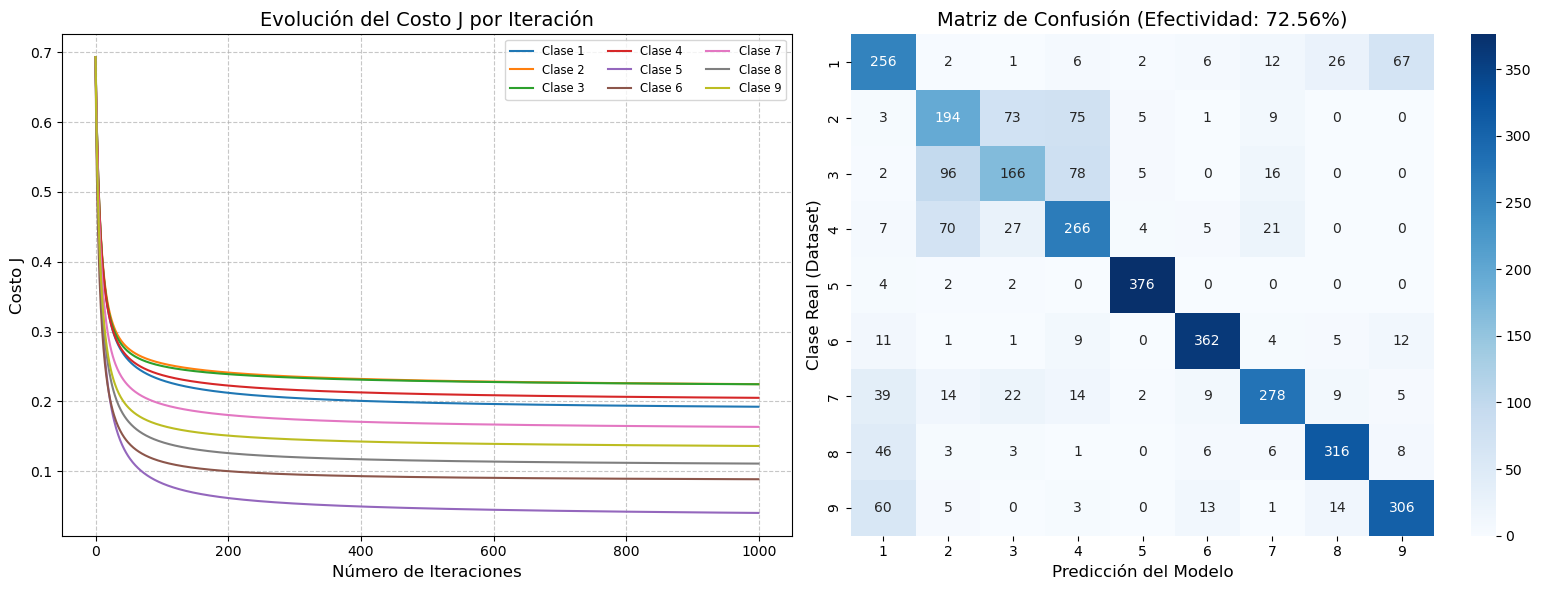

In [10]:
# Configuramos el tamaño del lienzo
plt.figure(figsize=(16, 6))

# --- 1. GRÁFICA DE COSTO (Demuestra el Aprendizaje) ---
plt.subplot(1, 2, 1)
# Dibujamos la línea de costo para cada una de las 9 clases
for i in range(num_labels):
    plt.plot(all_J_history[i], label=f'Clase {i+1}')

plt.title("Evolución del Costo J por Iteración", fontsize=14)
plt.xlabel("Número de Iteraciones", fontsize=12)
plt.ylabel("Costo J", fontsize=12)
plt.legend(loc='upper right', fontsize='small', ncol=3)
plt.grid(True, linestyle='--', alpha=0.7)

# --- 2. GRÁFICA DE EFECTIVIDAD / PRECISIÓN (Matriz de Confusión) ---
plt.subplot(1, 2, 2)
# Usamos todo el 20% de prueba (pred_test y y_test) para demostrar la efectividad real
cm = confusion_matrix(y_test, pred_test)

# Creamos un mapa de calor (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 10), yticklabels=range(1, 10))
plt.title(f"Matriz de Confusión (Efectividad: {acc_test:.2f}%)", fontsize=14)
plt.xlabel("Predicción del Modelo", fontsize=12)
plt.ylabel("Clase Real (Dataset)", fontsize=12)

# Ajustamos el espacio y mostramos
plt.tight_layout()
plt.show()

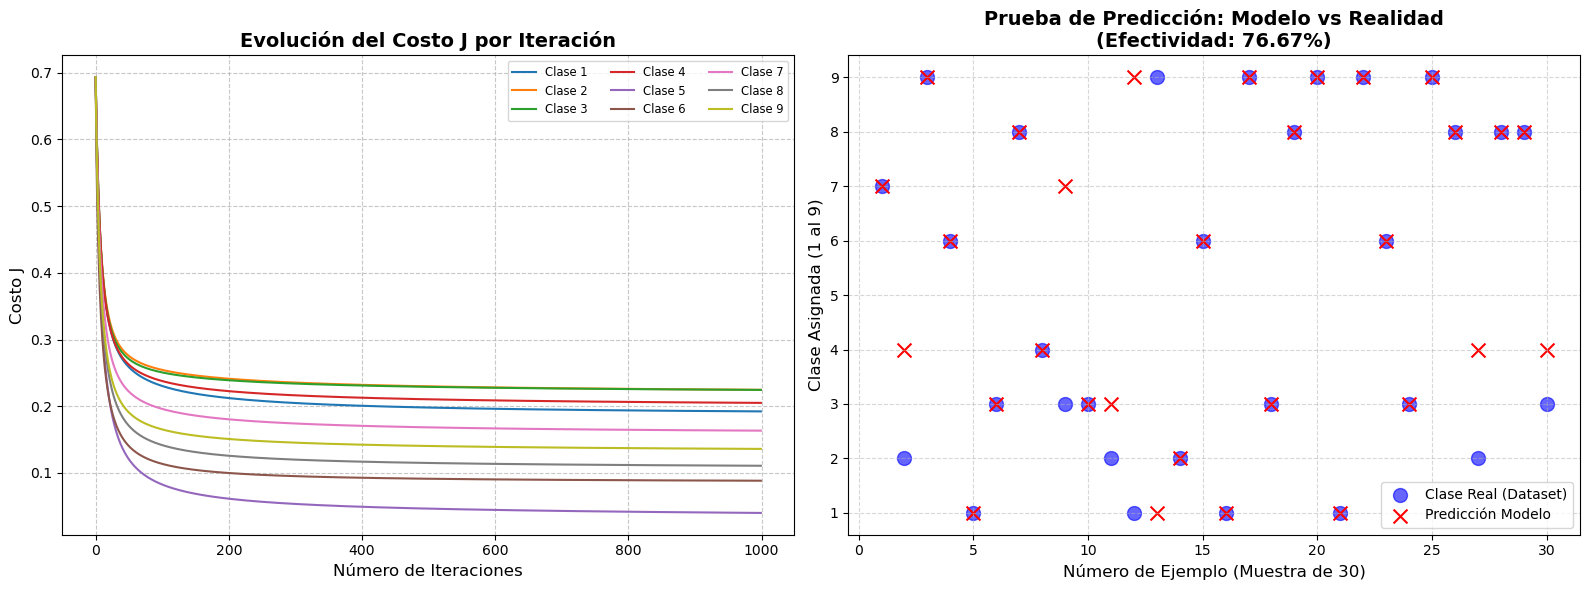

In [11]:
# Creamos un lienzo amplio con 2 espacios
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
# all_J_history tiene el costo de las 9 clases
for i in range(num_labels):
    plt.plot(all_J_history[i], label=f'Clase {i+1}')

plt.title("Evolución del Costo J por Iteración", fontsize=14, fontweight='bold')
plt.xlabel("Número de Iteraciones", fontsize=12)
plt.ylabel("Costo J", fontsize=12)
plt.legend(loc='upper right', fontsize='small', ncol=3)
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
# predicciones_muestra y y_real_muestra
eje_x = np.arange(1, 31) # Números del 1 al 30 para el eje X

# Dibujamos los puntos reales (Azules) y las predicciones (Equis Rojas)
plt.scatter(eje_x, y_real_muestra, color='blue', label='Clase Real (Dataset)', alpha=0.6, s=100)
plt.scatter(eje_x, predicciones_muestra, color='red', marker='x', label='Predicción Modelo', s=100)

plt.title(f"Prueba de Predicción: Modelo vs Realidad\n(Efectividad: {(aciertos_muestra/30)*100:.2f}%)", fontsize=14, fontweight='bold')
plt.xlabel("Número de Ejemplo (Muestra de 30)", fontsize=12)
plt.ylabel("Clase Asignada (1 al 9)", fontsize=12)
plt.yticks(range(1, 10)) # Forzamos que el eje Y muestre del 1 al 9
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()